<a href="https://colab.research.google.com/github/kyathamkarthik/datacenter-power-consumption-prediction/blob/main/notebooks/power_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/kyathamkarthik/datacenter-power-consumption-prediction/refs/heads/main/powerconsumption.csv"

df = pd.read_csv(url)

df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [4]:
# Check Dataset Statistics

df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360




1.   Load dataset
2.   Convert time column
3.   Prepare dataset for time-series analysis
4.   Preview data
5.   Analyze dataset structure
6.   Generate statistics
7.   List item
*   This stage is called EDA (Exploratory Data Analysis).

      **Why This Is Important For Your Project**
       
* Before building any ML model, data scientists must:


1.   Understand the data
2.   Check data quality
3.   Analyze patterns









In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/kyathamkarthik/datacenter-power-consumption-prediction/refs/heads/main/powerconsumption.csv"
df = pd.read_csv(url)

# Convert Datetime column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set Datetime as index
df = df.set_index('Datetime')

# Show first rows
print("Dataset preview:")
print(df.head())

# Check dataset structure
print("\nDataset information:")
print(df.info())

# Summary statistics
print("\nDataset statistics:")
print(df.describe())

Dataset preview:
                     Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
Datetime                                                                     
2017-01-01 00:00:00        6.559      73.8      0.083                0.051   
2017-01-01 00:10:00        6.414      74.5      0.083                0.070   
2017-01-01 00:20:00        6.313      74.5      0.080                0.062   
2017-01-01 00:30:00        6.121      75.0      0.083                0.091   
2017-01-01 00:40:00        5.921      75.7      0.081                0.048   

                     DiffuseFlows  PowerConsumption_Zone1  \
Datetime                                                    
2017-01-01 00:00:00         0.119             34055.69620   
2017-01-01 00:10:00         0.085             29814.68354   
2017-01-01 00:20:00         0.100             29128.10127   
2017-01-01 00:30:00         0.096             28228.86076   
2017-01-01 00:40:00         0.085             27335.69620   

        

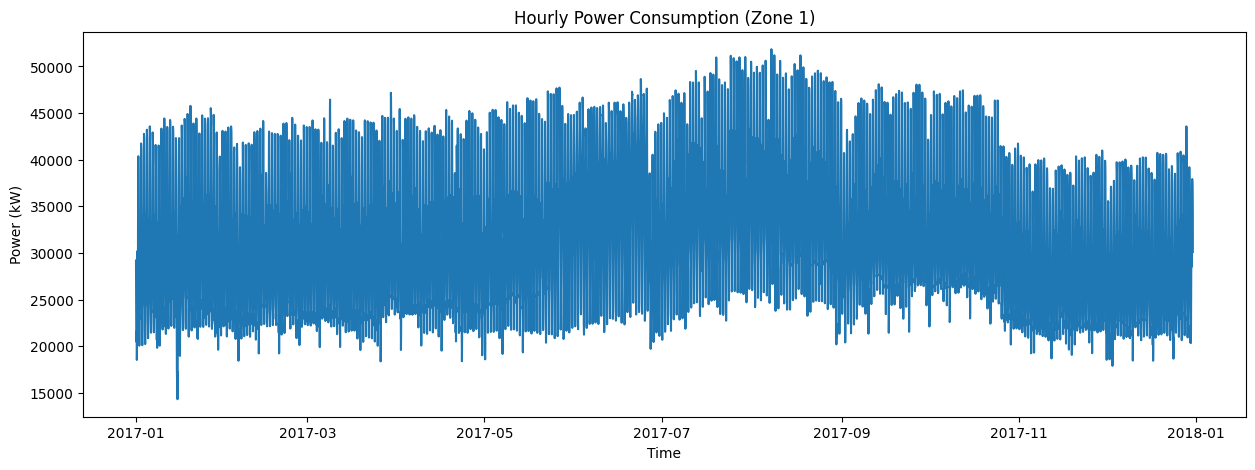

In [9]:
# Create hourly resampled data
df_hourly = df['PowerConsumption_Zone1'].resample('h').mean()

# Visualize Power Consumption Trend
plt.figure(figsize=(15,5))
plt.plot(df_hourly)

plt.title("Hourly Power Consumption (Zone 1)")
plt.xlabel("Time")
plt.ylabel("Power (kW)")

plt.savefig("power_trend.png")  # save image
plt.show()

**Correlation Heatmap**
* This shows how variables influence power usage

**Which features affect power:**
* Temperature
* Humidity
* Wind Speed
* Time


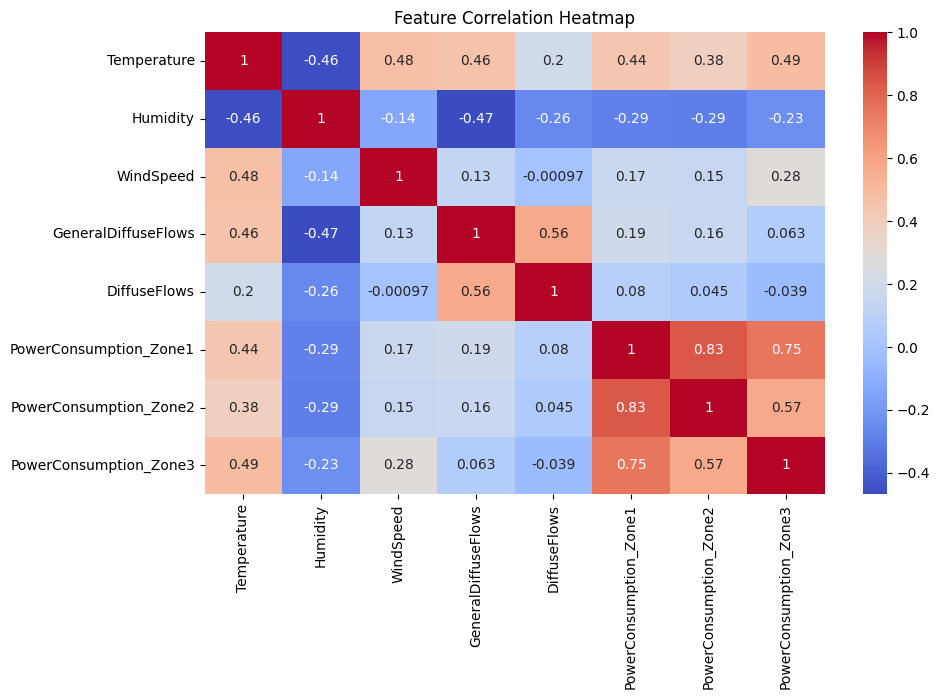

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**Feature Engineering (VERY IMPORTANT)**
* Machine learning models learn better when we create **time features**

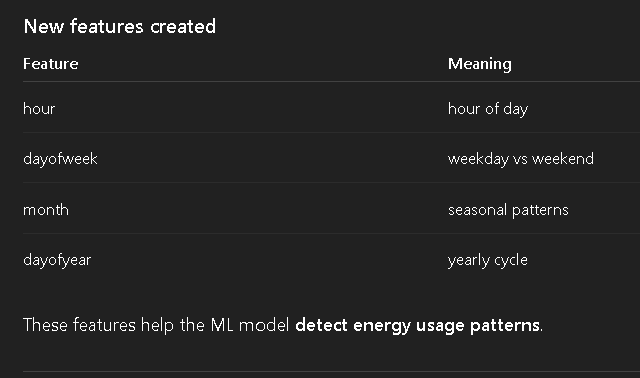

## Feature Engineering

Feature engineering is the process of creating meaningful variables
that help the machine learning model understand patterns in the data.

In this step we extract time-based features such as hour, day of week,
month, and day of year from the datetime index.

In [11]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)

df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,dayofweek,month,dayofyear
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


## Cyclical Time Encoding

Time-based features such as hour and day of year follow cyclical patterns.
To help the model understand these periodic patterns,
we encode them using sine and cosine transformations.

In [12]:
# Cyclical time features
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

df['day_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

## Lag Features

Power consumption often depends on previous usage patterns.
Lag features represent the power consumption values from previous time steps,
allowing the model to capture temporal dependencies.

In [13]:
# Lag features (previous power consumption)
df['lag1'] = df['PowerConsumption_Zone1'].shift(1)
df['lag2'] = df['PowerConsumption_Zone1'].shift(2)
df['lag3'] = df['PowerConsumption_Zone1'].shift(3)

# Rolling averages
df['rolling_mean_3'] = df['PowerConsumption_Zone1'].rolling(3).mean()
df['rolling_mean_6'] = df['PowerConsumption_Zone1'].rolling(6).mean()

# Remove NaN rows created by lag features
df = df.dropna()

**Define Features for ML Model**

* Now your dataset is ready for machine learning training.(after defining features)

In [14]:
FEATURES = [
'hour',
'dayofweek',
'month',
'dayofyear',
'Temperature',
'Humidity',
'WindSpeed',
'hour_sin',
'hour_cos',
'day_sin',
'day_cos',
'lag1',
'lag2',
'lag3',
'rolling_mean_3',
'rolling_mean_6'
]
TARGET = 'PowerConsumption_Zone1'

X = df[FEATURES]
y = df[TARGET]

print(X.head())

                     hour  dayofweek  month  dayofyear  Temperature  Humidity  \
Datetime                                                                        
2017-01-01 00:50:00     0          6      1          1        5.853      76.9   
2017-01-01 01:00:00     1          6      1          1        5.641      77.7   
2017-01-01 01:10:00     1          6      1          1        5.496      78.2   
2017-01-01 01:20:00     1          6      1          1        5.678      78.1   
2017-01-01 01:30:00     1          6      1          1        5.491      77.3   

                     WindSpeed  hour_sin  hour_cos   day_sin   day_cos  \
Datetime                                                                 
2017-01-01 00:50:00      0.081  0.000000  1.000000  0.017213  0.999852   
2017-01-01 01:00:00      0.080  0.258819  0.965926  0.017213  0.999852   
2017-01-01 01:10:00      0.085  0.258819  0.965926  0.017213  0.999852   
2017-01-01 01:20:00      0.081  0.258819  0.965926  0.017213  

**Install XGBoost**

In [15]:
!pip install xgboost

**Import ML Libraries**

In [16]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

**Split Dataset**

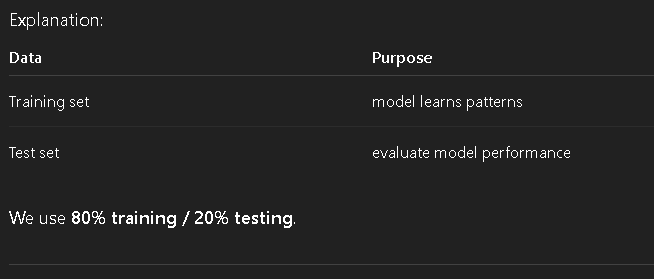

In [17]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

**Train the XGBoost Model**

*   This trains the **AI model**.
*   The model learns patterns like:
   * high temperature → higher cooling → higher power
daytime → more server usage

## Model Training

In this step we train an XGBoost regression model.
XGBoost is a powerful gradient boosting algorithm that
can capture complex relationships between input features and power consumption.



In [18]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

**Make Predictions**

* Now the model predicts **future power consumption**.

In [19]:
predictions = model.predict(X_test)

**Evaluate Model Accuracy**

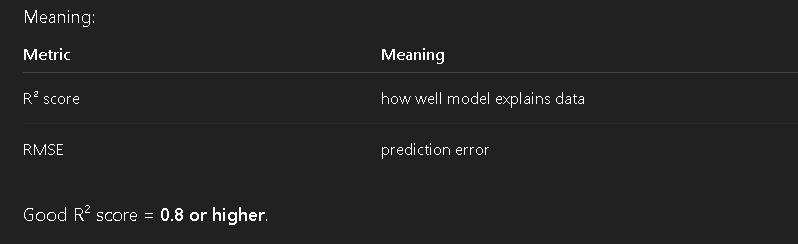

## Model Evaluation

The model performance is evaluated using two metrics:

• R² Score — indicates how well the model explains variance in the data.  
• RMSE — measures the average prediction error.

In [20]:
import numpy as np

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.9984373760896875
RMSE: 243.76436177054595


**Feature Importance (Very Important)**
* This shows which factors affect power consumption the most.

**This graph will show something like:**
1. Temperature → most important
2. hour → second
3. humidity → third

## Feature Importance Analysis

The XGBoost model provides feature importance scores that indicate how much each feature contributes to predicting power consumption.

Key observations:
- Temperature strongly influences cooling demand in data centers.
- Hour of the day captures daily workload cycles.
- Humidity also affects cooling efficiency.

This helps data center operators understand which environmental factors affect energy consumption the most.


<Figure size 1000x600 with 0 Axes>

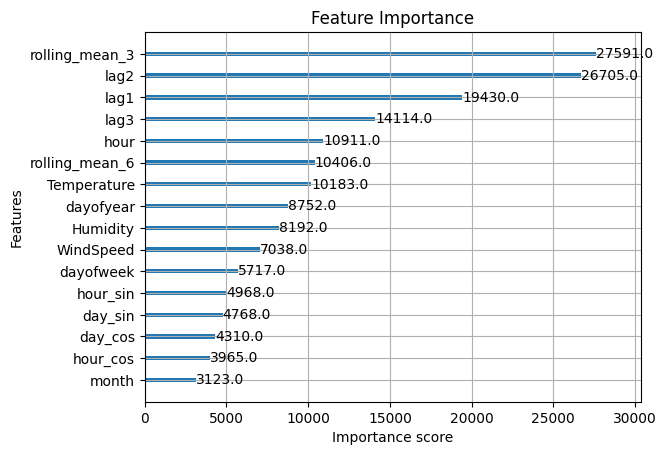

In [21]:


import xgboost as xgb

plt.figure(figsize=(10,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

**Predict Future Power**
* Now we simulate **future power demand.**

This cell demonstrates:
* AI model can predict future energy demand

## Example explanation for your report:

The trained XGBoost model can predict future power consumption using environmental conditions and time-based features. This helps data center operators estimate upcoming energy demand and plan resource allocation.


In [23]:
# Example: Predict power consumption for a future scenario

import numpy as np

future_input = pd.DataFrame({
    'hour': [14],
    'dayofweek': [2],
    'month': [7],
    'dayofyear': [182],
    'Temperature': [30],
    'Humidity': [45],
    'WindSpeed': [10]
})

# cyclical features
future_input['hour_sin'] = np.sin(2 * np.pi * future_input['hour'] / 24)
future_input['hour_cos'] = np.cos(2 * np.pi * future_input['hour'] / 24)

future_input['day_sin'] = np.sin(2 * np.pi * future_input['dayofyear'] / 365)
future_input['day_cos'] = np.cos(2 * np.pi * future_input['dayofyear'] / 365)

# lag features (example values)
future_input['lag1'] = df['PowerConsumption_Zone1'].iloc[-1]
future_input['lag2'] = df['PowerConsumption_Zone1'].iloc[-2]
future_input['lag3'] = df['PowerConsumption_Zone1'].iloc[-3]

# rolling means
future_input['rolling_mean_3'] = df['PowerConsumption_Zone1'].rolling(3).mean().iloc[-1]
future_input['rolling_mean_6'] = df['PowerConsumption_Zone1'].rolling(6).mean().iloc[-1]

future_prediction = model.predict(future_input)

print("Predicted Power Consumption:", round(future_prediction[0],2), "kW")

Predicted Power Consumption: 28936.0 kW


**Lag features representing previous power consumption values were used to capture temporal dependencies in energy demand.**

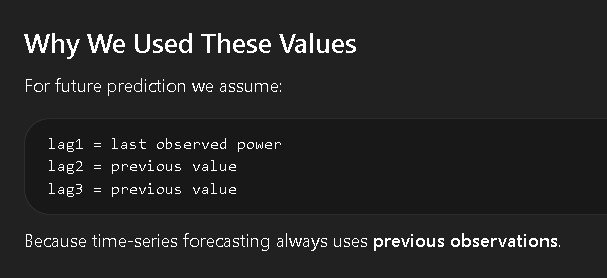